# Assessing Bicycle Lane Quality Using Smartphone Sensor Data

This notebook contains the complete data analysis pipeline for
classifying bicycle-lane sections as Smooth or Bumpy using
smartphone sensor data.

The analysis includes data loading, preprocessing, feature
extraction, feature selection, supervised and unsupervised
learning, model evaluation, and deployment.

> **Group members:**
>
> | Name | Student number |
> |---|---|
> | Himanshu Khartade | 2431459 |
> | *fill in* | *fill in* |
> | *fill in* | *fill in* |
>
> Participants are referred to as **P1, P2, P3** everywhere else (data files, plots, text) to keep the data anonymous.

# Environment and Reproducibility
The Python environment and package versions are recorded below to
support reproducibility.

In [228]:
import sys

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score

print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.3.5
scikit-learn: 1.9.0
matplotlib: 3.10.0


# Study Design & Data Collection

**Aim** Build a tool that classifies bike-lane surface quality — *smooth* or *bumpy* — from the motion sensors of a
smartphone.

**Participants** 3 group members (P1-P3), all course participants who can bike and have no condition that prevents
cycling. Every participant recorded one smooth and one bumpy ride.

**Sensors & settings** Sensor Logger app; accelerometer, gyroscope and gravity sensor only (all other sensors
off); default 100 Hz; *Standardisation* option on so iOS and Android exports are comparable.

**Procedure** Start recording → put the phone on the basket → ride the lane continuously → stop → take
the phone out → stop recording. Lane choice followed the protocol: *smooth* = a typical red cycling lane without imperfections;
*bumpy* = a commonly used lane with noticeable but not dangerous imperfections (small potholes, cracks, uneven surface).

**Data management**
- `data/raw/` — untouched exports, one folder per participant and condition, consistent names, anonymized (P1-P3).
- `data/processed/` — everything the notebook derives (merged + trimmed recordings, window features), stored separately.

In [229]:
Collection_info = {'P1':{'Phone':'iphone 15', 'placement':'Vertical on bicycle basket'},
                   'P2':{'Phone':'iphone 13', 'placement':'Vertical on bicycle basket'},
                   'P3':{'Phone':'iphone 17 pro max', 'placement':'Vertical on bicycle basket'}}

Route_info = {'P1_smooth': 'Near Geldropsedijk bus stop','P1_bumpy': 'Eisenhowerlaan',
    'P2_smooth': 'Near Geldropsedijk bus stop','P2_bumpy': '',
    'P3_smooth': '','P3_bumpy': ''}

In [230]:
def load_and_merge(acc_path, grav_path, gyro_path):
    """
    Load accelerometer, gravity, and gyroscope data and combine
    them using their timestamps.
    """

    acc = pd.read_csv(acc_path).rename(
        columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'}
    )

    grav = pd.read_csv(grav_path).rename(
        columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'}
    )

    gyro = pd.read_csv(gyro_path).rename(
        columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'}
    )

    # Check that all recordings have the same number of observations
    if not (len(acc) == len(grav) == len(gyro)):
        raise ValueError("Sensor files have different numbers of rows.")

    # Check timestamp alignment
    if not acc['time'].equals(grav['time']):
        raise ValueError("Accelerometer and gravity timestamps are not aligned.")

    if not acc['time'].equals(gyro['time']):
        raise ValueError("Accelerometer and gyroscope timestamps are not aligned.")

    # Combine the sensor measurements
    df = acc[
        ['time', 'seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']
    ].copy()

    df[['grav_x', 'grav_y', 'grav_z']] = grav[
        ['grav_x', 'grav_y', 'grav_z']
    ]

    df[['gyro_x', 'gyro_y', 'gyro_z']] = gyro[
        ['gyro_x', 'gyro_y', 'gyro_z']
    ]

    return df


In [231]:
# Define the location of each participant's recordings

recordings = {
    'P1_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P1'
    },
    'P1_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P1'
    },
    'P2_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P2'
    },
    'P2_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P2'
    },
    'P3_smooth': {
        'label': 'smooth',
        'folder': 'data_raw/Smooth/P3'
    },
    'P3_bumpy': {
        'label': 'bumpy',
        'folder': 'data_raw/Bumpy/P3'
    }
}

In [232]:
# Dictionary to store the merged data for each recording
merge_recordings = {}

for name, recording in recordings.items():

    folder = recording['folder']

# Load and merge accelerometer, gravity, and gyroscope data
    df = load_and_merge(
        f"{folder}/Accelerometer.csv",
        f"{folder}/Gravity.csv",
        f"{folder}/Gyroscope.csv")

# Store the merged data using the recording name
    merge_recordings[name] = df
    
# Display the number of samples and recording duration
    print(
        f"{name}: "
        f"{len(df)} rows, "
        f"{df['seconds_elapsed'].max():.1f} seconds"
    )

P1_smooth: 7719 rows, 77.3 seconds
P1_bumpy: 18010 rows, 180.4 seconds
P2_smooth: 12576 rows, 126.8 seconds
P2_bumpy: 19553 rows, 197.2 seconds
P3_smooth: 4763 rows, 47.8 seconds
P3_bumpy: 7583 rows, 76.2 seconds


## 3. Data Quality Assessment & Exploratory Data Analysis

Before any modeling: is the data complete and regular, and do the rides look like what they are supposed to be?

Per recording: sample count, duration, effective sampling rate, largest gap between samples, missing values and duplicated
timestamps. (Timestamp alignment of the three sensors was already asserted while loading.)

In [233]:
def recording_quality(key, df):
    t = df['seconds_elapsed'].values

    participant = key.split('_')[0]

    # Return a dictionary containing metadata and calculated quality metrics
    return {
        'recording': key,
    
        'participant':participant,

        # Look up device and placement metadata from the external Collection_info dictionary
        'phone': Collection_info[participant]['Phone'],   
        'placement': Collection_info[participant]['placement'],

        # Look up route metadata from the external Route_info dictionary
        'route': Route_info[key],  

        'rows': len(df),
        # Calculate total duration in seconds (last timestamp minus first timestamp)
        'duration_s': round(t[-1] - t[0], 1),

        # Calculate effective sampling frequency (Hz): (Total intervals) / (Total duration)
        'effective_hz': round(
            (len(t) - 1) / (t[-1] - t[0]), 1),

        # Count the total number of missing (NaN) values across all columns in the DataFrame
        'missing_values': int(
            df.isna().sum().sum()),

        # Count how many timestamps in the 'time' column are exact duplicates
        'duplicate_timestamps': int(
            df['time'].duplicated().sum()),
    }

# Create a summary DataFrame aggregating the quality metrics for all recordings
quality = pd.DataFrame(
    [
        recording_quality(name, df)
        for name, df in merge_recordings.items()
    ]
).set_index('recording')

display(quality)
t_dur = round(quality['duration_s'].sum() / 60,1)
print(f'Total duration: {t_dur} mins')

,participant,phone,placement,route,rows,duration_s,effective_hz,missing_values,duplicate_timestamps
recording,,,,,,,,,
P1_smooth,P1,iphone 15,Vertical on bicycle basket,Near Geldropsedijk bus stop,7719,77.3,99.9,0,0
P1_bumpy,P1,iphone 15,Vertical on bicycle basket,Eisenhowerlaan,18010,180.3,99.9,0,0
P2_smooth,P2,iphone 13,Vertical on bicycle basket,Near Geldropsedijk bus stop,12576,126.7,99.2,0,0
P2_bumpy,P2,iphone 13,Vertical on bicycle basket,,19553,197.1,99.2,0,0
P3_smooth,P3,iphone 17 pro max,Vertical on bicycle basket,,4763,47.8,99.6,0,0
P3_bumpy,P3,iphone 17 pro max,Vertical on bicycle basket,,7583,76.1,99.6,0,0


Total duration: 11.8 mins


# Data Preprocessing

In [234]:
# Calculate the overall acceleration magnitude
def signal_summary(df):
    magnitude = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

    return {
        'std': magnitude.std(),
        'max': magnitude.max()
    }

rows = {}

for name, df in merge_recordings.items():
    rows[name] = signal_summary(df)


magnitude_quality = (
    pd.DataFrame(rows).round(2)
    )

display(magnitude_quality)

,P1_smooth,P1_bumpy,P2_smooth,P2_bumpy,P3_smooth,P3_bumpy
std,0.97,3.47,0.93,2.68,0.76,2.67
max,10.23,55.13,8.68,47.01,10.52,27.80


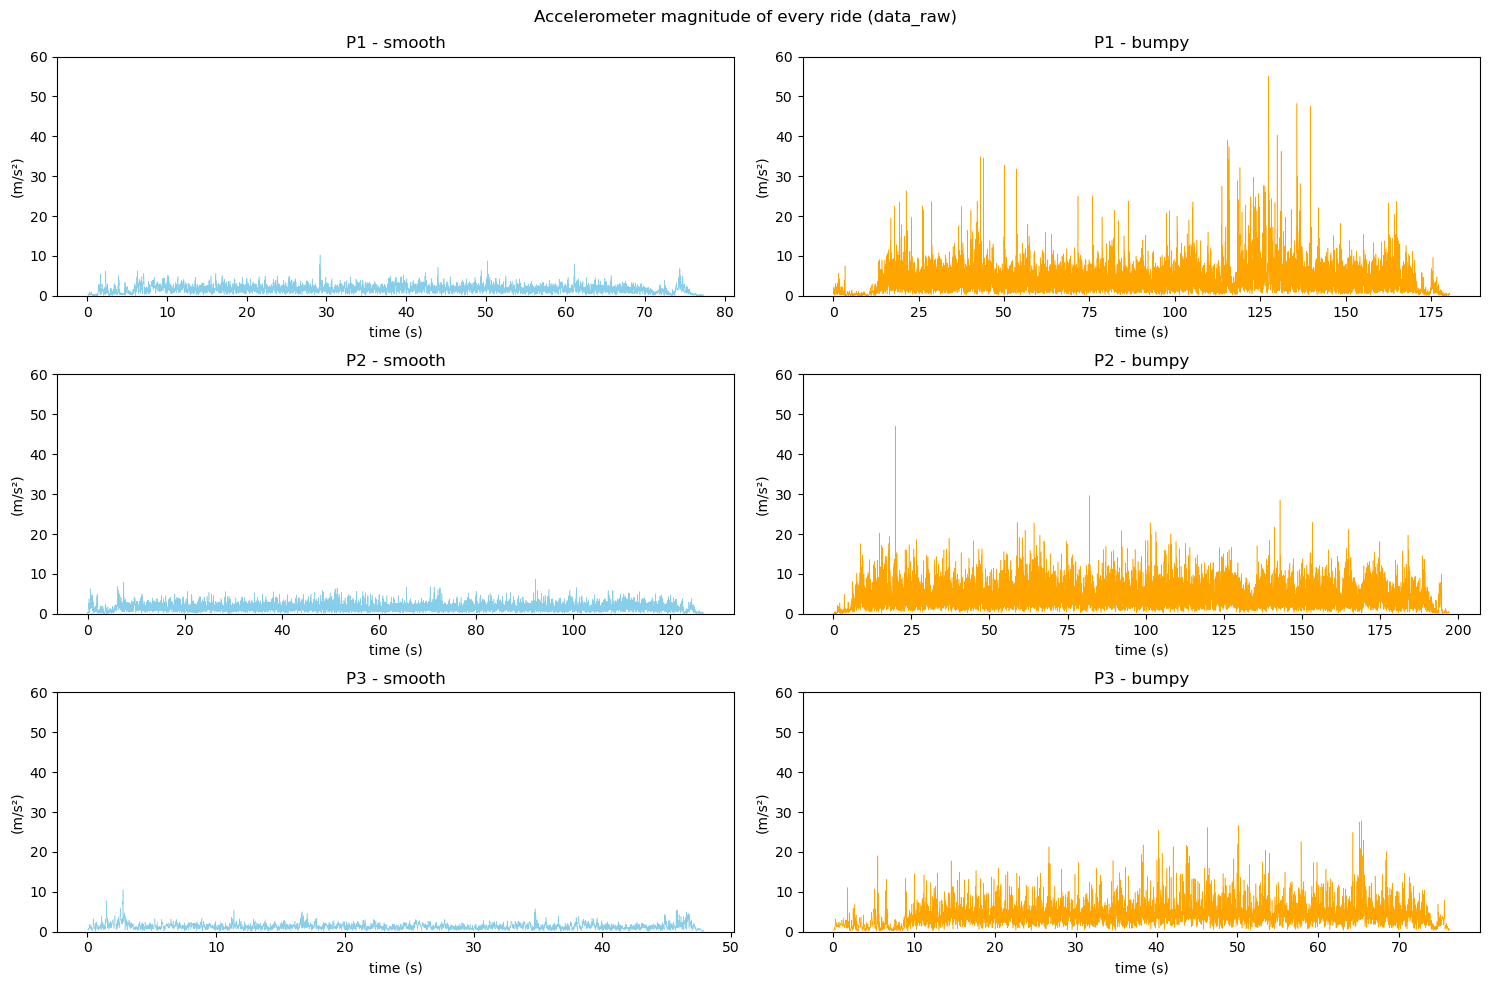

In [235]:
#Visualization of accelerometer magnitude of every ride

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for i, participant in enumerate(['P1', 'P2', 'P3']):

    for j, label in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{participant}_{label}']
        magnitude = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

        if label == 'smooth':color = 'skyblue' 
        else:color = 'orange'
        
        axes[i,j].plot(df['seconds_elapsed'], magnitude, color, lw = 0.4)
        axes[i, j].set_title(f'{participant} - {label}')
        axes[i, j].set_ylim(0, 60)
        axes[i, j].set_ylabel('(m/s²)')
        axes[i, j].set_xlabel('time (s)')


plt.suptitle('Accelerometer magnitude of every ride (data_raw)')
plt.tight_layout()
plt.show()


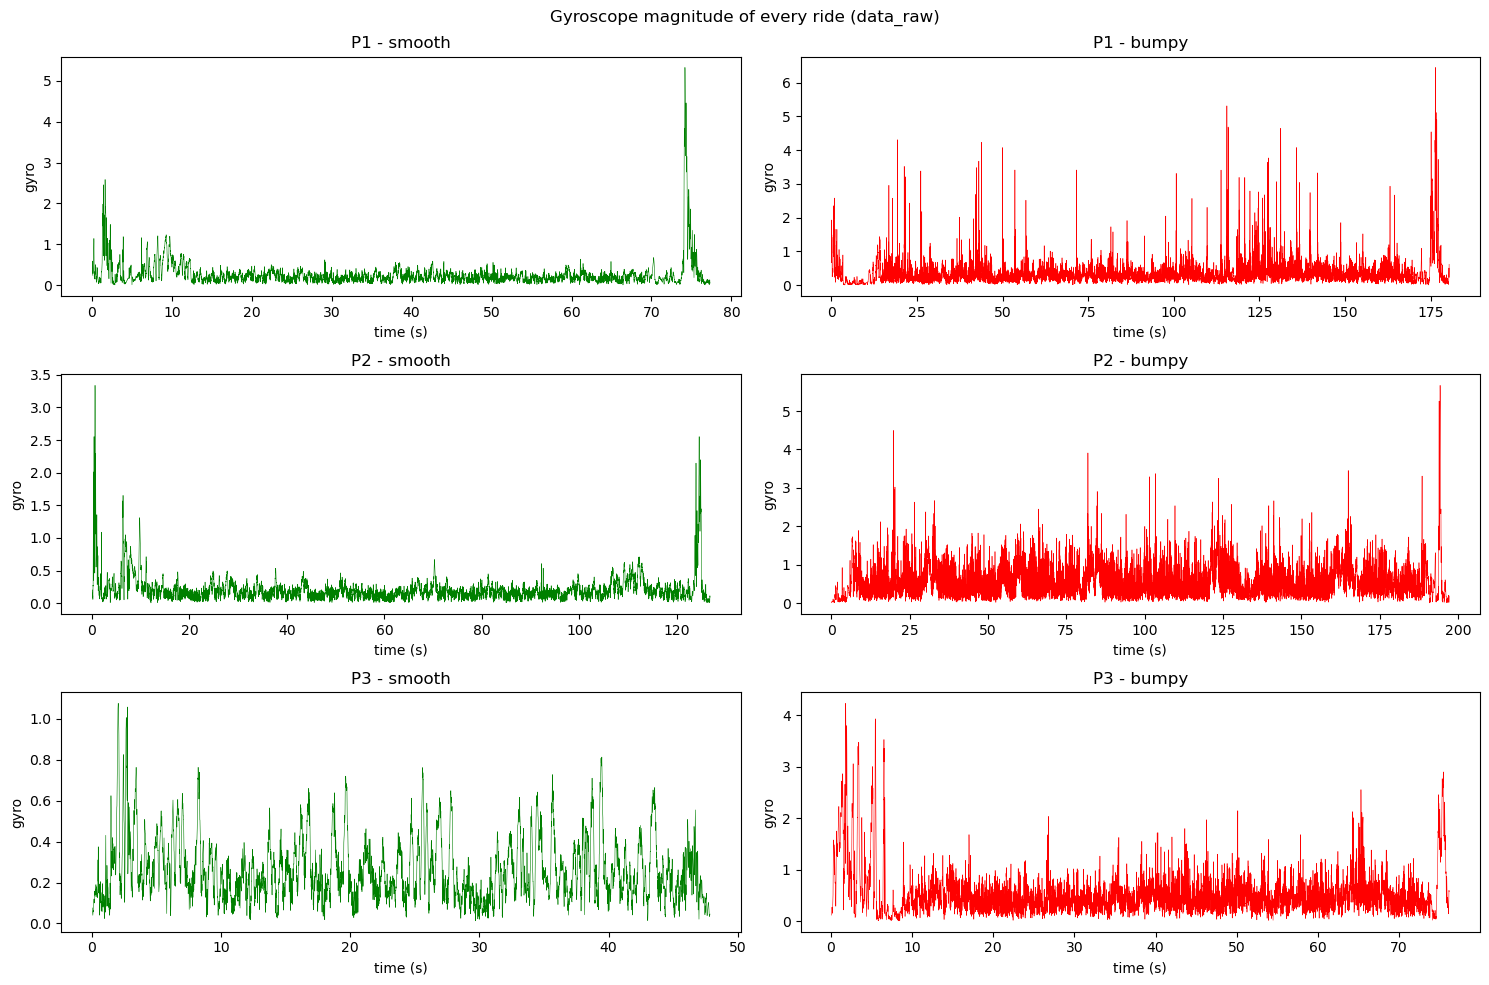

In [236]:
#Visualization of gyroscope magnitude of every ride

fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for i, participant in enumerate(['P1', 'P2', 'P3']):

    for j, label in enumerate(['smooth', 'bumpy']):

        df = merge_recordings[f'{participant}_{label}']
        magnitude = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

        if label == 'smooth':color = 'green' 
        else:color = 'red'
        
        axes[i,j].plot(df['seconds_elapsed'], magnitude, color, lw = 0.4)
        axes[i, j].set_title(f'{participant} - {label}')
        axes[i, j].set_ylabel('gyro')
        axes[i, j].set_xlabel('time (s)')


plt.suptitle('Gyroscope magnitude of every ride (data_raw)')
plt.tight_layout()
plt.show()

# Feature Engineering & Extraction

Windowing strategy

In [237]:
Sampling_freq = 100
steps = 1
windows = 2

window_size = Sampling_freq * windows
step_size = Sampling_freq * steps

def create_window(df, window_size, step_size):
    windows_data = []

    for right in range (0, len(df)-window_size+1, step_size):
        left = right + window_size
        windows_data.append(df.iloc[right:left].copy())
    return windows_data

In [238]:
for name, df in merge_recordings.items():
    participant_windows = create_window(df, window_size, step_size)
    print(name," |rows-", len(df), " |duration-", round(df['seconds_elapsed'].iloc[-1],2), " |windows-",len(participant_windows))


P1_smooth  |rows- 7719  |duration- 77.32  |windows- 76
P1_bumpy  |rows- 18010  |duration- 180.36  |windows- 179
P2_smooth  |rows- 12576  |duration- 126.8  |windows- 124
P2_bumpy  |rows- 19553  |duration- 197.15  |windows- 194
P3_smooth  |rows- 4763  |duration- 47.85  |windows- 46
P3_bumpy  |rows- 7583  |duration- 76.18  |windows- 74


Feature Extraction

In [239]:
def extract_features(window):
    acc_magnitude = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    grav_magnitude = np.sqrt(window['grav_x']**2+window['grav_y']**2+window['grav_z']**2)
    gyro_magnitude = np.sqrt(window['gyro_x']**2+window['gyro_y']**2+window['gyro_z']**2)

    features = {
        # Accelerometer
        'acc_std': acc_magnitude.std(),
        'acc_mean': acc_magnitude.mean(),
        'acc_rms': np.sqrt(np.mean(acc_magnitude**2)),
        'acc_min': acc_magnitude.min(),
        'acc_max': acc_magnitude.max(),

        # Gyroscope
        'gyro_std': gyro_magnitude.std(),
        'gyro_mean': gyro_magnitude.mean(),
        'gyro_rms': np.sqrt(np.mean(gyro_magnitude**2)),
        'gyro_min': gyro_magnitude.min(),
        'gyro_max': gyro_magnitude.max(),

        # Gravity
        'grav_std': grav_magnitude.std(),
        'grav_mean': grav_magnitude.mean(),
        'grav_rms': np.sqrt(np.mean(grav_magnitude**2)),
        'grav_min': grav_magnitude.min(),
        'grav_max': grav_magnitude.max()
    }

    return features

    

In [240]:
#Features dataframe showing mean, standard deviation, minimum, maximun and root mean square
feature_data = []

for header, df in merge_recordings.items():
    participant, label = header.split('_')
    participant_windows = create_window(df, window_size, step_size)
    
    for window_id, window in enumerate(participant_windows):
        feature = extract_features(window)
        feature['Window_id'] = window_id
        feature['participant'] = participant
        feature['label'] = label

        feature_data.append(feature)

feature_df = pd.DataFrame(feature_data)
print(feature_df.head())
print('\n',feature_df.shape)
print('\n', feature_df['label'].value_counts)


    acc_std  acc_mean   acc_rms   acc_min   acc_max  gyro_std  gyro_mean  \
0  1.010505  0.886185  1.342140  0.061957  5.520825  0.631305   0.672880   
1  1.214302  1.358877  1.820358  0.068112  6.236351  0.639781   0.725582   
2  1.122946  1.324076  1.734324  0.068112  6.236351  0.327587   0.381427   
3  0.904788  1.173593  1.480496  0.138823  5.025217  0.225030   0.286697   
4  0.676839  0.970845  1.182523  0.091636  3.377678  0.109840   0.190313   

   gyro_rms  gyro_min  gyro_max      grav_std  grav_mean  grav_rms  grav_min  \
0  0.921586  0.037141  2.586651  4.035689e-07    9.80665   9.80665  9.806649   
1  0.966304  0.005605  2.586651  6.089114e-07    9.80665   9.80665  9.806648   
2  0.502259  0.005605  1.488414  7.061292e-07    9.80665   9.80665  9.806648   
3  0.364116  0.008595  1.187420  7.661682e-07    9.80665   9.80665  9.806648   
4  0.219599  0.008595  0.495067  8.015115e-07    9.80665   9.80665  9.806648   

   grav_max  Window_id participant   label  
0  9.806651      

In [241]:
#Converting features into X and y variables to create a trainable dataset
X_feature_ext = ['acc_std','acc_mean','acc_rms','acc_min','acc_max',
                  'gyro_std','gyro_mean','gyro_rms','gyro_min','gyro_max',
                  'grav_std','grav_mean','grav_rms','grav_min','grav_max']

X_features = feature_df[X_feature_ext]
y_feature = feature_df['label']

print("X shape:", X_features.shape)
print("y shape:", y_feature.shape)


X shape: (693, 15)
y shape: (693,)


In [242]:
#Correlation between features
corr  = X_features.corr()
display(corr.round(2))

,acc_std,acc_mean,acc_rms,acc_min,acc_max,gyro_std,gyro_mean,gyro_rms,gyro_min,gyro_max,grav_std,grav_mean,grav_rms,grav_min,grav_max
acc_std,1.00,0.94,0.97,0.56,0.96,0.43,0.40,0.42,0.25,0.68,0.11,0.38,0.38,0.05,0.19
acc_mean,0.94,1.00,0.99,0.68,0.87,0.33,0.41,0.39,0.32,0.57,0.07,0.38,0.38,0.11,0.13
acc_rms,0.97,0.99,1.00,0.65,0.91,0.37,0.41,0.41,0.31,0.61,0.08,0.38,0.38,0.09,0.15
acc_min,0.56,0.68,0.65,1.00,0.53,0.17,0.33,0.28,0.31,0.31,-0.05,0.23,0.23,0.17,-0.04
acc_max,0.96,0.87,0.91,0.53,1.00,0.41,0.37,0.40,0.23,0.68,0.08,0.36,0.36,0.07,0.14
gyro_std,0.43,0.33,0.37,0.17,0.41,1.00,0.87,0.95,0.29,0.87,-0.19,0.14,0.14,0.16,-0.04
gyro_mean,0.40,0.41,0.41,0.33,0.37,0.87,1.00,0.98,0.60,0.74,-0.30,0.12,0.12,0.30,-0.17
gyro_rms,0.42,0.39,0.41,0.28,0.40,0.95,0.98,1.00,0.51,0.82,-0.26,0.13,0.13,0.26,-0.13
gyro_min,0.25,0.32,0.31,0.31,0.23,0.29,0.60,0.51,1.00,0.34,-0.15,0.04,0.04,0.20,-0.10
gyro_max,0.68,0.57,0.61,0.31,0.68,0.87,0.74,0.82,0.34,1.00,-0.08,0.23,0.23,0.13,0.04


Feature Selection

In [243]:
'''
Feature selection is the important process in the feature engineering
As seen in the above output gravity features were not making any difference in dataset, their varaince was very low
We are choosing only the features which shows variance and correlation
'''

X_feature_selection = [
    'acc_std','acc_mean','acc_rms','acc_min','acc_max',
    'gyro_std','gyro_mean','gyro_rms','gyro_min','gyro_max'
]

X_features_selected = feature_df[X_feature_selection]
y_feature_selected = feature_df['label']

print("X shape:", X_features_selected.shape)
print("y shape:", y_feature_selected.shape)

X shape: (693, 10)
y shape: (693,)


In [244]:
#Correlation between features
corr  = X_features_selected.corr()
display(corr.round(2))

,acc_std,acc_mean,acc_rms,acc_min,acc_max,gyro_std,gyro_mean,gyro_rms,gyro_min,gyro_max
acc_std,1.00,0.94,0.97,0.56,0.96,0.43,0.40,0.42,0.25,0.68
acc_mean,0.94,1.00,0.99,0.68,0.87,0.33,0.41,0.39,0.32,0.57
acc_rms,0.97,0.99,1.00,0.65,0.91,0.37,0.41,0.41,0.31,0.61
acc_min,0.56,0.68,0.65,1.00,0.53,0.17,0.33,0.28,0.31,0.31
acc_max,0.96,0.87,0.91,0.53,1.00,0.41,0.37,0.40,0.23,0.68
gyro_std,0.43,0.33,0.37,0.17,0.41,1.00,0.87,0.95,0.29,0.87
gyro_mean,0.40,0.41,0.41,0.33,0.37,0.87,1.00,0.98,0.60,0.74
gyro_rms,0.42,0.39,0.41,0.28,0.40,0.95,0.98,1.00,0.51,0.82
gyro_min,0.25,0.32,0.31,0.31,0.23,0.29,0.60,0.51,1.00,0.34
gyro_max,0.68,0.57,0.61,0.31,0.68,0.87,0.74,0.82,0.34,1.00


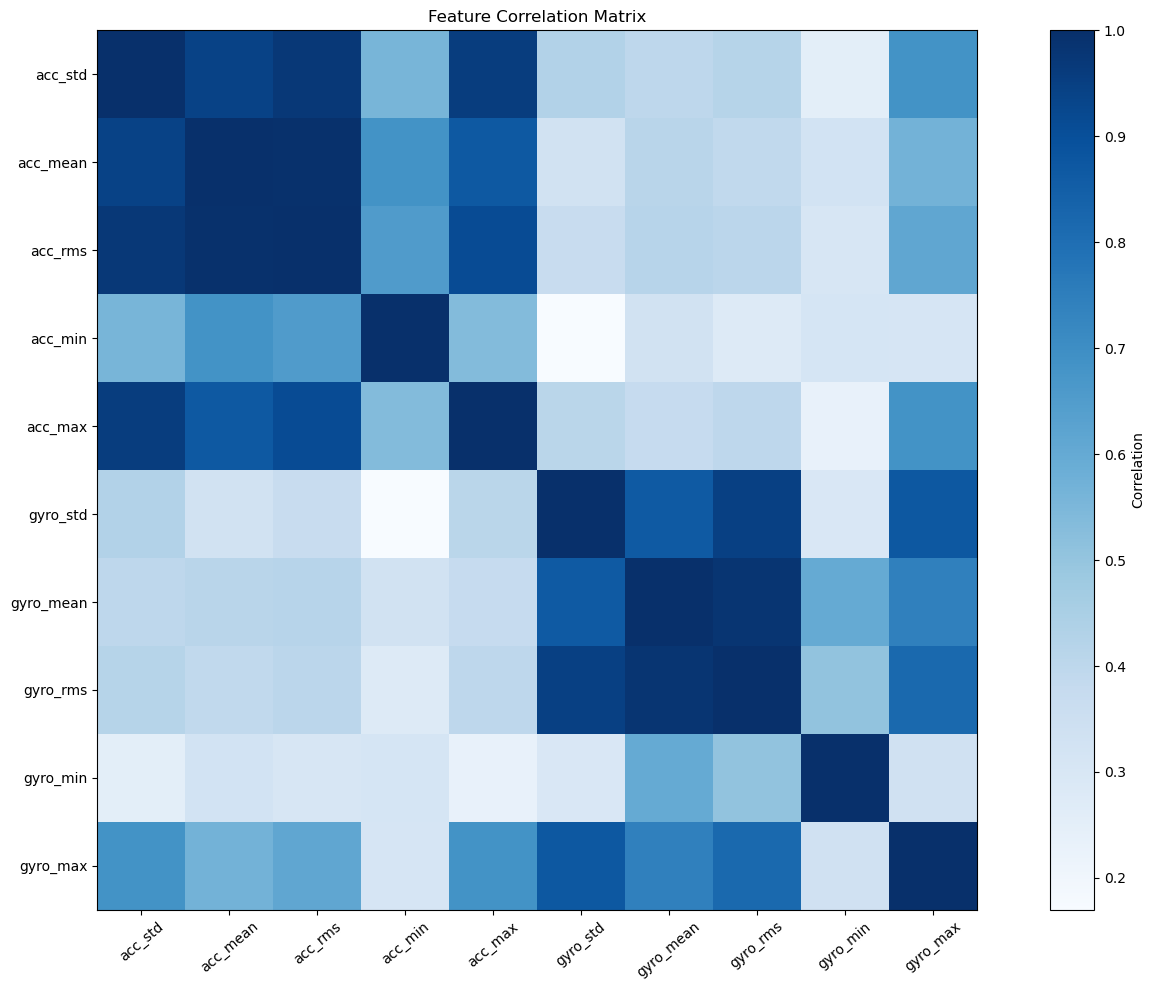

In [245]:
#Visualization of correlation 
plt.figure(figsize=(15, 10))

plt.imshow(corr, cmap='Blues')

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=40,
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label='Correlation')
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

Mutual Information

In [246]:
from sklearn.feature_selection import mutual_info_classif

y_num = y_feature_selected.map({
    'smooth':0,
    'bumpy':1
})

mi = mutual_info_classif(X_features_selected, y_feature_selected, random_state=42)

mi_df = pd.DataFrame({
    'Feature':X_features_selected.columns,
    'Mutual information': mi}
)

mi_df = mi_df.sort_values('Mutual information', ascending=False)

display(mi_df.round(2))

,Feature,Mutual information
2,acc_rms,0.54
4,acc_max,0.53
1,acc_mean,0.52
0,acc_std,0.51
9,gyro_max,0.41
5,gyro_std,0.31
7,gyro_rms,0.29
6,gyro_mean,0.29
3,acc_min,0.28
8,gyro_min,0.15


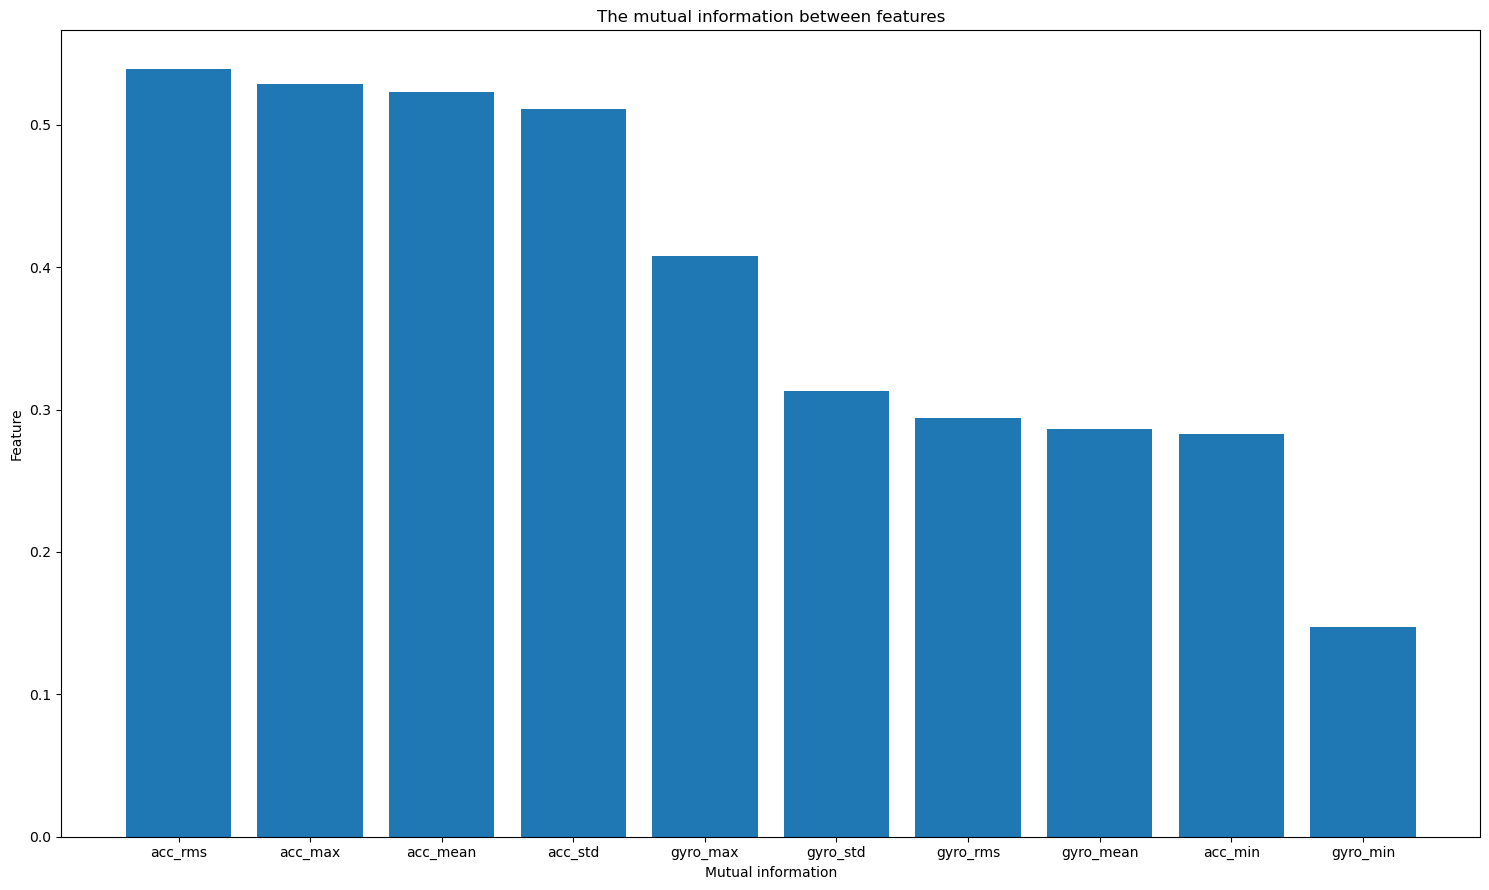

In [247]:
#Visualize the mutual information between features
plt.figure(figsize=(15,9))

plt.bar(mi_df['Feature'],mi_df['Mutual information'])

plt.xlabel('Mutual information')
plt.ylabel('Feature')
plt.title('The mutual information between features')

plt.tight_layout()
plt.show()



# Supervised Learning

Building pipeline of supervised models

In [248]:
def build_supervised_model(model):

        X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)
        #Scale the data 
        sc = StandardScaler()

        X_train_sc = sc.fit_transform(X_train)
        X_test_sc = sc.transform(X_test)

        #Apply PCA in training set
        pca = PCA(n_components=0.95) #varaince at 95%

        X_train_pca = pca.fit_transform(X_train_sc)
        X_test_pca = pca.transform(X_test_sc)

        #Model training 
        model.fit(X_train_pca, y_train)

        #Prediction on trained model
        y_pred = model.predict(X_test_pca)

        #Different types of validation of a model
        accuracy = accuracy_score(y_test, y_pred)
            
        cm = confusion_matrix(y_test, y_pred)
            
        f1_sc = f1_score(y_test, y_pred, pos_label='bumpy')
            
        re_sc = recall_score(y_test, y_pred, pos_label='bumpy')     

        df = pd.DataFrame({
        'accuracy':[accuracy],
        'confusion_matrix':[cm],
        'f1_score':[f1_sc],
        'recall_score':[re_sc]
        })

        return df.round(2) 



1. Logistic Regression

In [249]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_df = build_supervised_model(lr_model)
display(lr_df)

,accuracy,confusion_matrix,f1_score,recall_score
0,0.92,"[[118, 14], [2, 74]]",0.94,0.89


2. k-Nearest Neighbors (k-NN)

In [250]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_df = build_supervised_model(knn_model)
display(knn_df)

,accuracy,confusion_matrix,f1_score,recall_score
0,0.93,"[[120, 12], [3, 73]]",0.94,0.91


3. Random Forest Classifier

In [251]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=50, criterion='entropy', max_depth=10)
rf_df = build_supervised_model(rf_model)
display(rf_df)

,accuracy,confusion_matrix,f1_score,recall_score
0,0.93,"[[126, 6], [8, 68]]",0.95,0.95


4. Support Vector Classifier

In [252]:
from sklearn.svm import SVC
svc_model = SVC(kernel='rbf')
svc_df = build_supervised_model(svc_model)
display(svc_df)

,accuracy,confusion_matrix,f1_score,recall_score
0,0.92,"[[118, 14], [3, 73]]",0.93,0.89


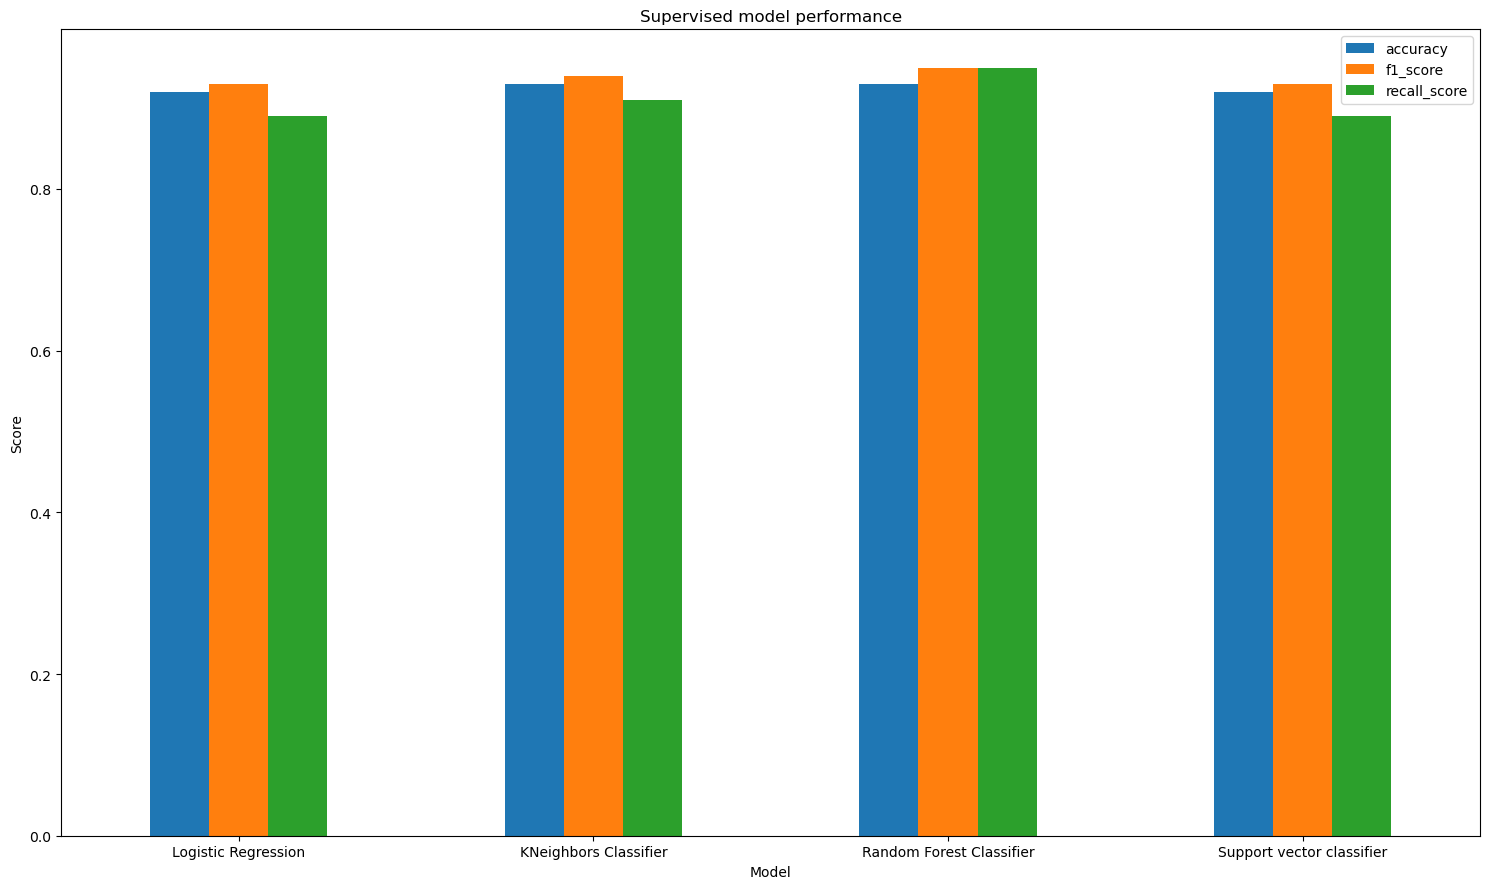

,accuracy,f1_score,recall_score
Logistic Regression,0.92,0.93,0.89
KNeighbors Classifier,0.93,0.94,0.91
Random Forest Classifier,0.93,0.95,0.95
Support vector classifier,0.92,0.93,0.89


In [253]:
#Visulaization of all models validation by mean
lr_mean = svc_df[['accuracy', 'f1_score', 'recall_score']].mean() 
knn_mean = knn_df[['accuracy', 'f1_score', 'recall_score']].mean() 
rf_mean = rf_df[['accuracy', 'f1_score', 'recall_score']].mean() 
svc_mean = svc_df[['accuracy', 'f1_score', 'recall_score']].mean() 

Total_mean = pd.DataFrame({
    'Logistic Regression':lr_mean,
    'KNeighbors Classifier':knn_mean,
    'Random Forest Classifier':rf_mean,
    'Support vector classifier':svc_mean
}).T #Transpose (models are rows and values are columns)

axes = Total_mean.plot(kind='bar', figsize=(15,9))

plt.title('Supervised model performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(Total_mean.round(2))


# Unsupervised Learning

1. Agglomerative Clustering

In [254]:
from sklearn.cluster import AgglomerativeClustering

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scag = sc.fit_transform(X_train)
X_test_scag = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcaag = pca.fit_transform(X_train_scag)
X_test_pcaag = pca.transform(X_test_scag)

model_ac = AgglomerativeClustering(n_clusters=2, linkage='ward') #'ward' linkage minimizes the variance of merged clusters
clusters = model_ac.fit_predict(X_test_pcaag)

#Check if the true values are aligned with clusters
cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_ag = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_ag = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
accuracy = accuracy_score(y_test, y_pred_ag)
            
cm = confusion_matrix(y_test, y_pred_ag)
            
f1_sc = f1_score(y_test, y_pred_ag, pos_label='bumpy')
            
re_sc = recall_score(y_test, y_pred_ag, pos_label='bumpy')     

agc_df = pd.DataFrame({
    'accuracy':[accuracy],
    'confusion_matrix':[cm],
    'f1_score':[f1_sc],
    'recall_score':[re_sc]
    })

display(agc_df.round(4))    

,accuracy,confusion_matrix,f1_score,recall_score
0,0.9038,"[[121, 11], [9, 67]]",0.9237,0.9167


2. K means Clustering

In [255]:
from sklearn.cluster import KMeans

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_sckm = sc.fit_transform(X_train)
X_test_sckm = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcakm = pca.fit_transform(X_train_sckm)
X_test_pcakm = pca.transform(X_test_sckm)

model_km = KMeans(n_clusters=2, random_state=42)
model_km.fit(X_train_pcakm)
clusters = model_km.predict(X_test_pcakm)

#Check if the true values are aligned with clusters
cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_km = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_km = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
accuracy = accuracy_score(y_test, y_pred_km)
            
cm = confusion_matrix(y_test, y_pred_km)
            
f1_sc = f1_score(y_test, y_pred_km, pos_label='bumpy')
            
re_sc = recall_score(y_test, y_pred_km, pos_label='bumpy')     

km_df = pd.DataFrame({
    'accuracy':[accuracy],
    'confusion_matrix':[cm],
    'f1_score':[f1_sc],
    'recall_score':[re_sc]
    })

display(km_df.round(4))    

c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,accuracy,confusion_matrix,f1_score,recall_score
0,0.875,"[[108, 24], [2, 74]]",0.8926,0.8182


3. Fuzzy C-Means Clustering

In [256]:
import skfuzzy as fuzz

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scfc = sc.fit_transform(X_train)
X_test_scfc = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcafc = pca.fit_transform(X_train_scfc)
X_test_pcafc = pca.transform(X_test_scfc)

cntr, u_train,_,_,_,_,_ = fuzz.cluster.cmeans(X_train_pcafc.T,2,m=2, error=0.005, maxiter=1000)

u_test,_,_,_,_,_= fuzz._cluster.cmeans_predict(X_test_pcafc.T, cntr,2,error=0.005, maxiter=1000)

clusters = np.argmax(u_test, axis=0)

cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_fc = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_fc = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
accuracy = accuracy_score(y_test, y_pred_fc)
            
cm = confusion_matrix(y_test, y_pred_fc)
            
f1_sc = f1_score(y_test, y_pred_fc, pos_label='bumpy')
            
re_sc = recall_score(y_test, y_pred_fc, pos_label='bumpy')     

fc_df = pd.DataFrame({
    'accuracy':[accuracy],
    'confusion_matrix':[cm],
    'f1_score':[f1_sc],
    'recall_score':[re_sc]
    })

display(fc_df.round(4))  

,accuracy,confusion_matrix,f1_score,recall_score
0,0.8798,"[[108, 24], [1, 75]]",0.8963,0.8182


4. Gaussian Mixture Model

In [257]:
from sklearn.mixture import GaussianMixture

X_train, X_test, y_train, y_test = train_test_split(X_features_selected, y_feature_selected, test_size=0.3, random_state=42)

y_test = y_test.reset_index(drop = True)

sc = StandardScaler()
X_train_scgm = sc.fit_transform(X_train)
X_test_scgm = sc.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pcagm = pca.fit_transform(X_train_scgm)
X_test_pcagm = pca.transform(X_test_scgm)

model_gmm = GaussianMixture(n_components=2, random_state=42)
model_gmm.fit(X_train_pcagm)

clusters = model_gmm.predict(X_test_pcagm)

cls_result = pd.crosstab(y_test, clusters)

#If cluster 0 has most of the actual bumpy windows
if cls_result.loc['bumpy', 0] > cls_result.loc['bumpy', 1]:
    #If yes then cluster 0 is bumpy and cluster 1 is smooth
    y_pred_gm = ['bumpy' if c == 0 else 'smooth' for c in clusters]
else:
    #If not then cluster 0 is smooth and cluster 1 is bumpy
    y_pred_gm = ['smooth' if c == 0 else 'bumpy' for c in clusters]

#Different types of validation of a model
accuracy = accuracy_score(y_test, y_pred_gm)
            
cm = confusion_matrix(y_test, y_pred_gm)
            
f1_sc = f1_score(y_test, y_pred_gm, pos_label='bumpy')
            
re_sc = recall_score(y_test, y_pred_gm, pos_label='bumpy')     

fc_df = pd.DataFrame({
    'accuracy':[accuracy],
    'confusion_matrix':[cm],
    'f1_score':[f1_sc],
    'recall_score':[re_sc]
    })

display(fc_df.round(4))  




c:\Users\Himanshu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,accuracy,confusion_matrix,f1_score,recall_score
0,0.9038,"[[125, 7], [13, 63]]",0.9259,0.947


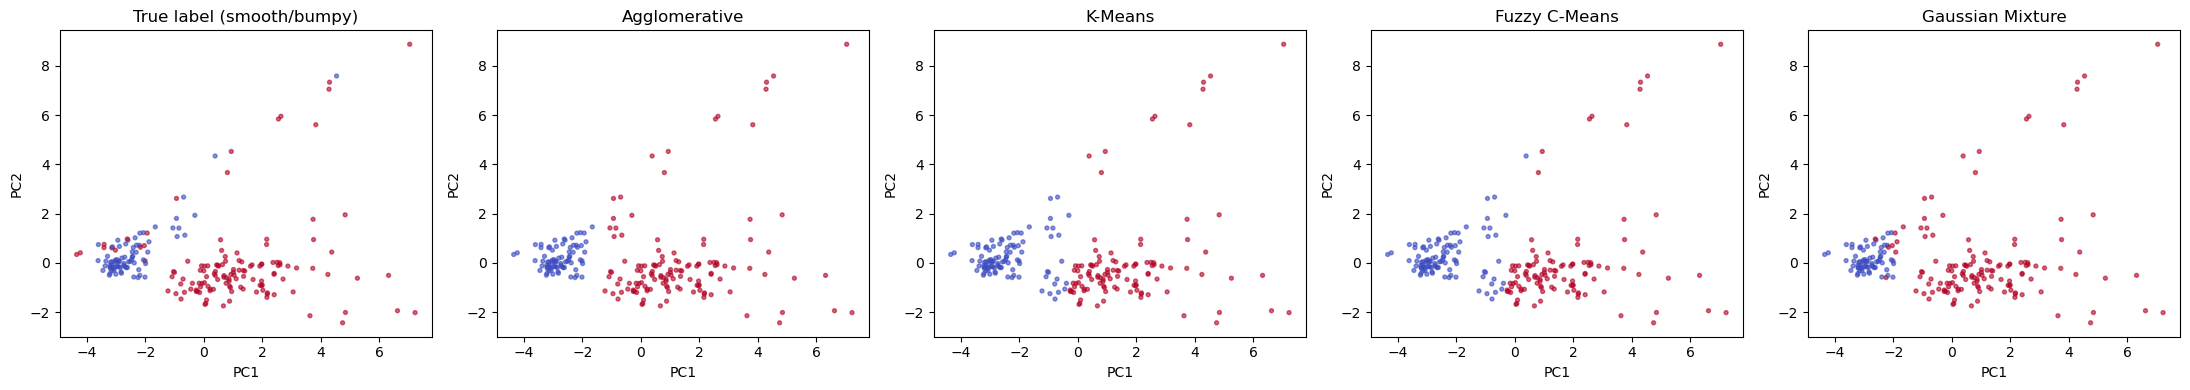

In [259]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the true string labels to 0 (smooth) and 1 (bumpy) for coloring
y_true_num = [1 if label == 'bumpy' else 0 for label in y_test]

results = [
    ('Agglomerative', [1 if p == 'bumpy' else 0 for p in y_pred_ag]),
    ('K-Means', [1 if p == 'bumpy' else 0 for p in y_pred_km]),
    ('Fuzzy C-Means', [1 if p == 'bumpy' else 0 for p in y_pred_fc]),
    ('Gaussian Mixture', [1 if p == 'bumpy' else 0 for p in y_pred_gm])
]

# 3. Select your PCA data (since the splits and PCA settings were identical, any of your test PCAs will work)
X_pca = X_test_pcakm 

# 4. Your plotting code (updated for consistent colors)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

# Plot True Labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true_num, cmap='coolwarm', s=8, alpha=0.6)
axes[0].set_title('True label (smooth/bumpy)')

# Plot Predicted Labels
for ax, (name, labels) in zip(axes[1:], results):
    # Changed cmap to 'coolwarm' so the colors match the True Label chart exactly
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm', s=8, alpha=0.6)
    ax.set_title(name)

# Apply axes labels
for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()